In [ ]:
import sys, os
import warnings
import pyidi
import matplotlib.pyplot as plt

from IPython.display import Video

In [2]:
sys.path.insert(0, os.path.realpath('__file__'))
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings('ignore')

# Video Reader

* Initially it was not created for PyIDI
* It was created while working on simulated video recordings
* Simulation was performed in Blender

## Example 1: Video in `mp4` format

* Video of Tacoma bridge

In [3]:
Video('../data/tacoma_bridge.mp4')

* Initialise `video` object

In [20]:
images_2 = pyidi.VideoReader('../data/tacoma_bridge.mp4')
print('Number of frames: ', images_2.N)
print('FPS: ', images_2.fps)

Number of frames:  248
FPS:  30.0


* Example of plotting a selected frame (151st) from the video file using red channel (other options are: `'G'`, `'B'` and `'Y'` which is default):

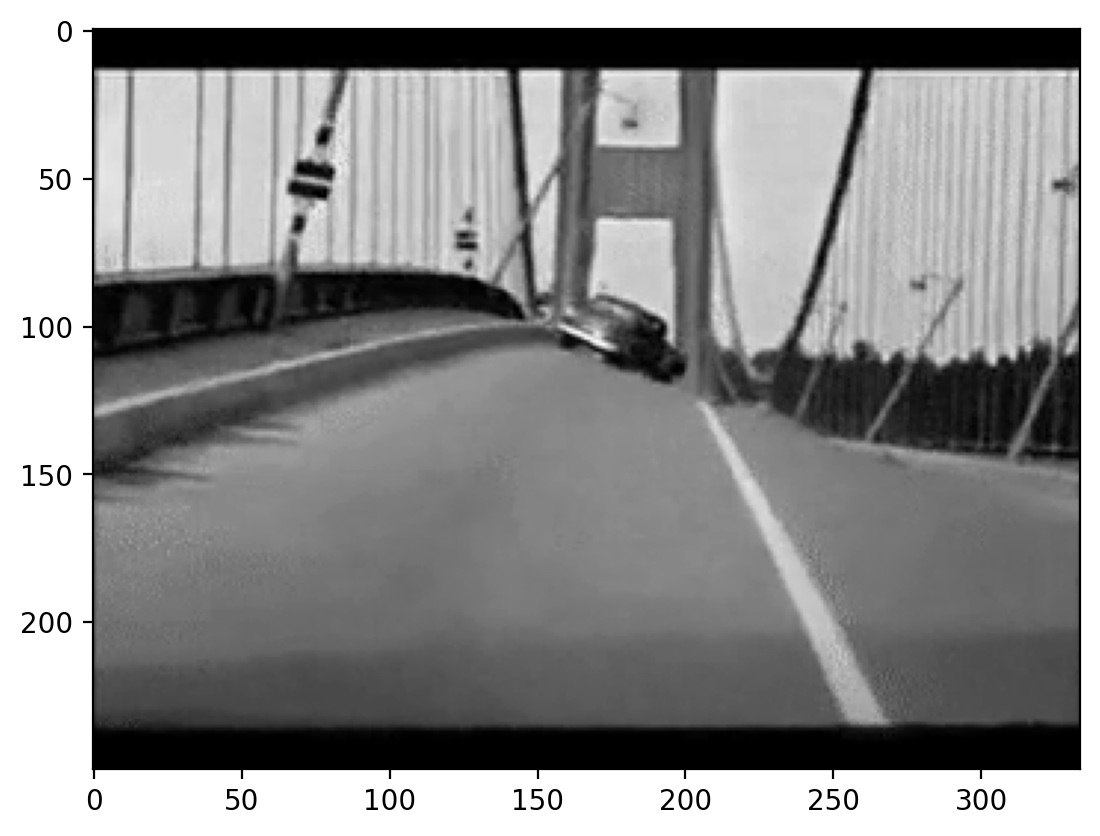

In [5]:
plt.imshow(images_2.get_frame(150, 'R'), cmap='grey')

* Initialise `PyIDI` object for displacement identification using patternmatchin LK method:

In [6]:
image_2_lk = pyidi.LucasKanade(images_2)

* Set the center point of Region Of Interest:

In [7]:
image_2_lk.set_points([[130, 100]])

* Set ROI size:

In [8]:
image_2_lk.configure(roi_size=(37, 37))

* Show ROI on the initial image:

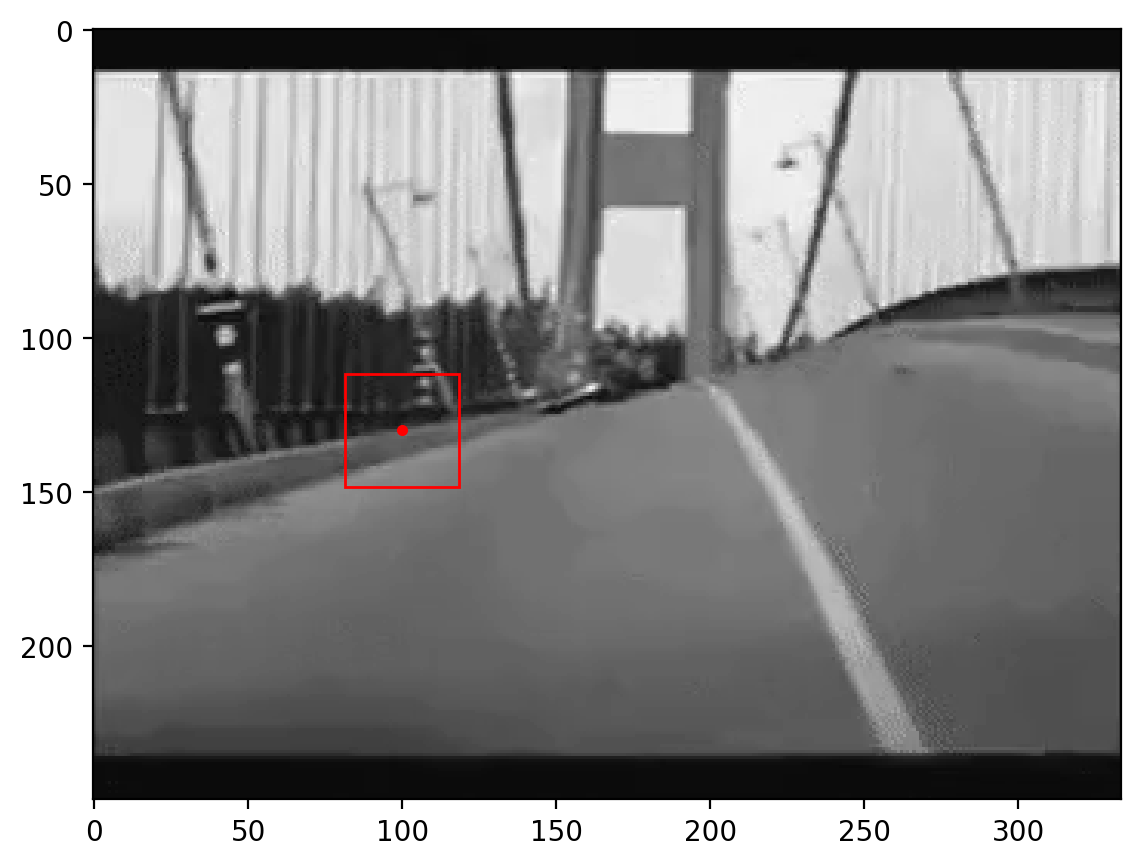

In [9]:
image_2_lk.show_points()

* Perform displacement identification:

In [10]:
dsp = image_2_lk.get_displacements(autosave=False)

Output()

--- Starting new analysis ---
 
Interpolating the reference image...
...done in 0.00 s


Time to complete: 3.7 s


* Show the results:

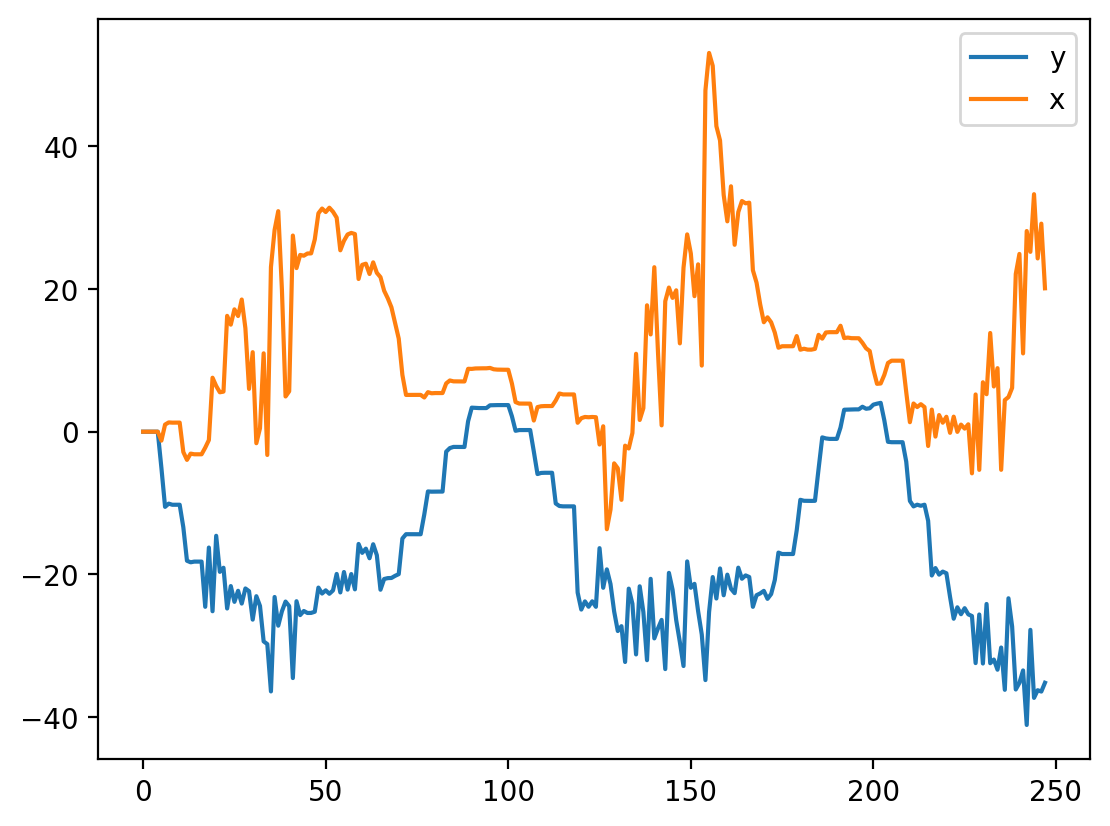

In [11]:
plt.plot(dsp[0, :, 0], label='y')
plt.plot(dsp[0, :, 1], label='x')
plt.legend()

## Example 2: Animated `gif`

* image formats such as: `gif`, `tiff` can contain multiple images
* animated gif of Tacoma bridge

<img src="../data/bridge-swinging.gif" width="50%">

* Initialise `video` object

In [12]:
images_3 = pyidi.VideoReader('../data/bridge-swinging.gif')
print('Number of frames: ', images_3.N)
print('FPS: ', images_3.image_meta.get('fps'))

Number of frames:  28
FPS:  10.0


* Example of plotting a selected frame (21st) from the video file:

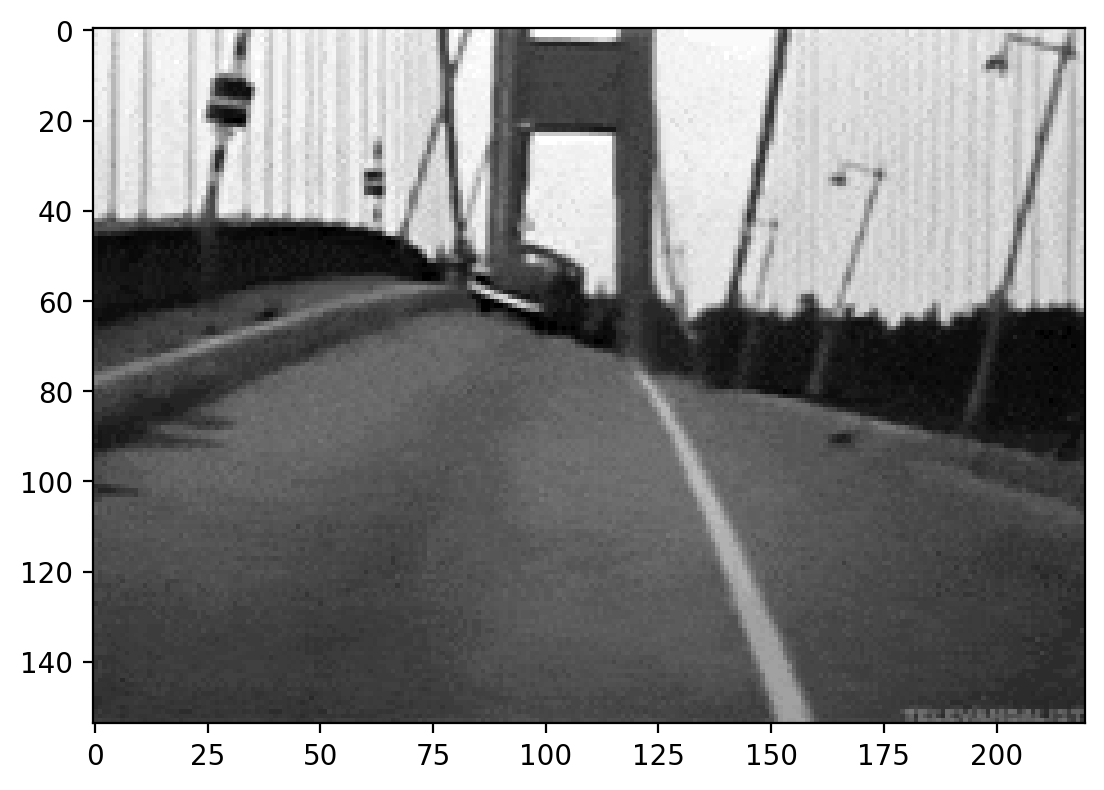

In [13]:
plt.imshow(images_3.get_frame(20), cmap='grey')

* Initialise `PyIDI` object for displacement identification using patternmatchin LK method:

In [14]:
image_3_lk = pyidi.LucasKanade(images_3)

* Set the center point of Region Of Interest:

In [15]:
image_3_lk.set_points([[65, 35]])

* Set ROI size:

In [16]:
image_3_lk.configure(roi_size=(23, 23))

* Show ROI on the initial image:

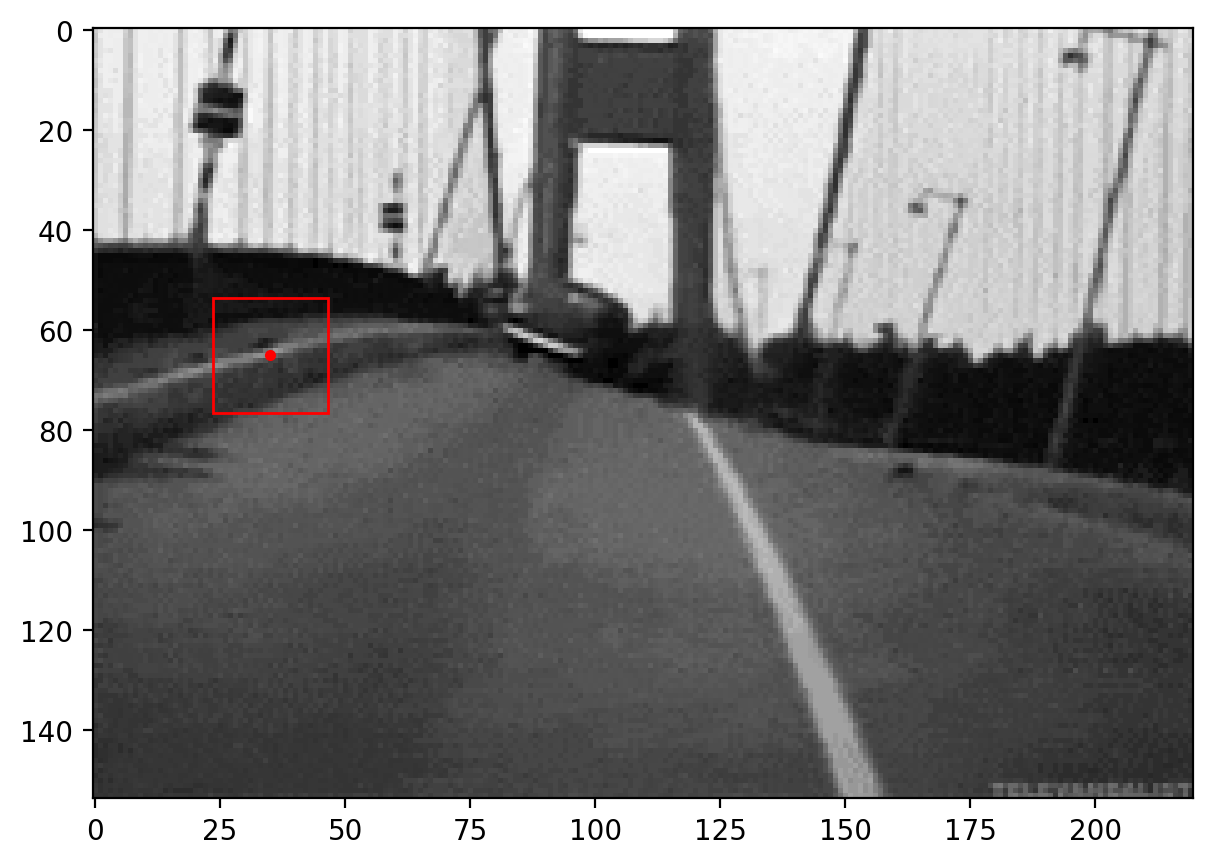

In [17]:
image_3_lk.show_points()

* Perform displacement identification:

In [18]:
dsp2 = image_3_lk.get_displacements(autosave=False)

Output()

--- Starting new analysis ---
 
Interpolating the reference image...
...done in 0.00 s


Time to complete: 0.1 s


* Show the results:

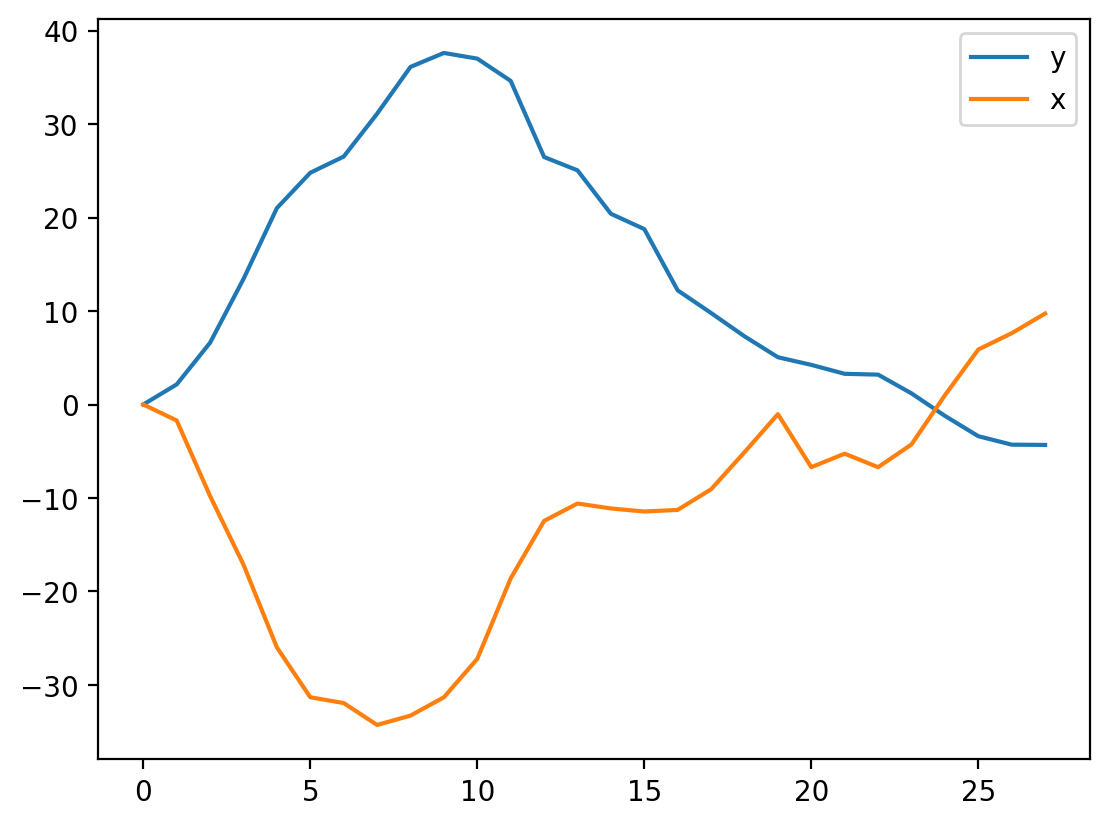

In [19]:
plt.plot(dsp2[0, :, 0], label='y')
plt.plot(dsp2[0, :, 1], label='x')
plt.legend()